# Мета-лейблинг: ML решает, СКОЛЬКО доверять альфа-портфелю

**Идея (López de Prado):** первичная стратегия — равновзвешенный портфель топ-5 альф —
даёт направление. Мета-модель на каждом баре предсказывает вероятность, что следующий
бар портфеля будет прибыльным, и **режет размер позиции** `s ∈ [0..1]`. Она *никогда не
переворачивает* сигнал — только приглушает. Именно это отличает её от RL-таймера из
прошлого эксперимента (который мог шортить и на этом сгорел).

**Правила честности — те же:**
1. Топ-5 по **fitness** (TEST в отборе не участвует), дедуп семейств.
2. Обучение и подбор — только TRAIN+VAL, с **purged walk-forward** кросс-валидацией
   (эмбарго 5 баров против утечки через автокорреляцию).
3. TEST — один прогон в самом конце.
4. Бустинг стохастичен → 5 сидов, отчёт по медиане.
5. Изменение размера платит 10 б.п. за единицу |Δs| — бесплатного тормоза не бывает.
6. Бейзлайны: «всегда полный размер» и **тупой inverse-vol троттлинг** — ML обязан
   бить не только always-on, но и правило из одной строчки, иначе он лишняя сложность.

Модели: логрег (линейный бейзлайн), HistGradientBoosting (бустинг деревьев),
и их ансамбль — среднее вероятностей.

In [1]:
import os, sys, json, warnings, difflib, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore'); np.seterr(all='ignore')
PROJ = os.getcwd()
S = json.load(open(os.path.join(PROJ, 'alphanode', 'gui_settings.json')))
TF = S.get('timeframe', '1d')
os.environ['ALPHANODE_TF'] = TF
sys.path[:0] = [os.path.join(PROJ, 'evolution'), PROJ]
from config import load_config
from evaluator import build_panel, make_market, eval_alpha_panel, basket_returns
from fastsim import fast_sim
from genome import parse

cfg = load_config()
ANN, FREQ = float(cfg.get('ann', 365.0)), cfg.get('freq', 'D')
VOL, EXEC = float(S['target_vol']), float(S['exec_cost'])
DATA = os.path.join(PROJ, 'data.pickle' if TF == '1d' else f'data_{TF}.pickle')
LIB = os.path.join(PROJ, 'alphanode', 'state',
                   'library.jsonl' if TF == '1d' else f'library_{TF}.jsonl')
TR, VA, TE, EN = (pd.Timestamp(S[k], tz='UTC') for k in
                  ('train_start', 'val_start', 'test_start', 'test_end'))
N_ALPHAS, SIZE_COST, EMBARGO, HGB_SEEDS = 5, 0.0010, 5, 5
print(f'tf={TF} ann={ANN:g} vol={VOL} exec={EXEC}')
print(f'TRAIN {TR.date()} .. VAL {VA.date()} .. TEST {TE.date()} .. {EN.date()}')

tf=1d ann=365 vol=0.36 exec=0.0005
TRAIN 2019-09-05 .. VAL 2021-11-01 .. TEST 2023-01-01 .. 2026-07-05


## 1. Первичная стратегия — тот же портфель топ-5, что и в RL-эксперименте

In [2]:
rows = [json.loads(l) for l in open(LIB, encoding='utf-8')]
rows = [r for r in rows if r.get('formula') and isinstance(r.get('base'), (int, float))]
rows.sort(key=lambda c: c['base'], reverse=True)
picked = []
for c in rows:
    if all(difflib.SequenceMatcher(None, c['formula'], p['formula']).ratio() < 0.80
           for p in picked):
        picked.append(c)
    if len(picked) == N_ALPHAS:
        break

tk, raw, panel = build_panel(DATA, TR.tz_localize(None).to_pydatetime(),
                             EN.tz_localize(None).to_pydatetime(), None, freq=FREQ)
market = make_market(panel, tk, raw, vol_window=cfg.get('vol_window', 30))
R = {}
for c in picked:
    ap = eval_alpha_panel(parse(c['formula']), panel)
    R[c['formula'][:40]] = fast_sim(ap[tk].to_numpy(dtype=np.float64), market, VOL, EXEC,
                                    ann=ANN, ewma_lambda=cfg.get('ewma_lambda', 0.06))
R = pd.DataFrame(R).fillna(0.0)
p = R.mean(axis=1)                                    # the primary: always-on alpha portfolio
idx = p.index
m_train = (idx >= TR) & (idx < VA)
m_val   = (idx >= VA) & (idx < TE)
m_test  = (idx >= TE) & (idx < EN)
m_sel   = m_train | m_val
print(f'{len(p)} bars · primary is the EW portfolio of {N_ALPHAS} family-distinct alphas')

2496 bars · primary is the EW portfolio of 5 family-distinct alphas


## 2. Фичи (только прошлое) и метка

Метка: `y(t) = 1`, если `p(t+1) > 0`. Вес примера — `|p(t+1)|`: модель должна
угадывать большие бары, мелочь неинтересна. Фичи описывают состояние портфеля,
согласие альф между собой и режим рынка.

In [3]:
F = pd.DataFrame(index=idx)
for w in (5, 21, 63):
    F[f'mom{w}'] = p.rolling(w).sum()
F['vol21'] = p.rolling(21).std() * np.sqrt(ANN)
eq = (1 + p).cumprod()
dd = eq / eq.cummax() - 1
F['dd'] = dd
F['dd_days'] = (dd < 0).astype(int).groupby((dd >= 0).cumsum()).cumsum()
for i, col in enumerate(R.columns):                    # each alpha's recent health
    r = R[col]
    F[f'a{i}_sh21'] = r.rolling(21).mean() / (r.rolling(21).std() + 1e-12)
F['disp'] = R.std(axis=1)                              # cross-alpha disagreement, today
pc = R.rolling(63).corr()                              # mean pairwise correlation, 63d
mask_od = ~np.eye(len(R.columns), dtype=bool)
F['acorr63'] = pc.groupby(level=0).apply(lambda m: m.values[mask_od].mean())
btc_col = next((c for c in panel['ret'].columns if 'BTC' in c), None)
btc = panel['ret'][btc_col].reindex(idx).fillna(0.0) if btc_col else basket_returns(panel).reindex(idx).fillna(0.0)
F['btc_mom21'], F['btc_mom63'] = btc.rolling(21).sum(), btc.rolling(63).sum()
F['btc_vol21'] = btc.rolling(21).std() * np.sqrt(ANN)
F['breadth'] = (panel['ret'].rolling(21).sum() > 0).mean(axis=1).reindex(idx)
if 'funding' in panel:
    F['funding'] = panel['funding'].mean(axis=1).rolling(7).mean().reindex(idx)

y = (p.shift(-1) > 0).astype(int)                      # will the NEXT bar be a winner?
w_smp = p.shift(-1).abs()
valid = (~F.isna().any(axis=1)) & w_smp.notna()
X = F.values
print(f'{X.shape[1]} features · usable bars {valid.sum()} of {len(p)} · '
      f'base rate P(win) on TRAIN+VAL = {y[valid & m_sel].mean():.2f}')

18 features · usable bars 2244 of 2496 · base rate P(win) on TRAIN+VAL = 0.56


## 3. Purged walk-forward на TRAIN+VAL — есть ли сигнал вообще?

Расширяющееся окно, 5 блоков, эмбарго 5 баров между train и validation.
AUC ≈ 0.50 — сигнала нет; стабильно > 0.53 — уже интересно.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

sel_ix = np.where(m_sel & valid.values)[0]

def make_logreg():
    return LogisticRegression(C=0.5, max_iter=2000)

def make_hgb(seed):
    return HistGradientBoostingClassifier(max_depth=3, max_leaf_nodes=7,
                                          learning_rate=0.05, max_iter=200,
                                          l2_regularization=1.0, random_state=seed)

def fit_predict(model, tr_ix, pr_ix, scale):
    sc = StandardScaler().fit(X[tr_ix]) if scale else None
    Xt = sc.transform(X[tr_ix]) if scale else X[tr_ix]
    Xp = sc.transform(X[pr_ix]) if scale else X[pr_ix]
    model.fit(Xt, y.values[tr_ix], sample_weight=w_smp.values[tr_ix])
    return model.predict_proba(Xp)[:, 1]

edges = np.linspace(0, len(sel_ix), 6).astype(int)
print(f'{"fold":4s} {"train":>6s} {"val":>5s} {"logreg":>7s} {"hgb":>6s} {"ens":>6s}')
cv_rows = []
for k, (a, b) in enumerate(zip(edges[1:-1], edges[2:])):
    tr_ix = sel_ix[:max(0, a - EMBARGO)]
    va_ix = sel_ix[a:b]
    pl = fit_predict(make_logreg(), tr_ix, va_ix, scale=True)
    ph = np.mean([fit_predict(make_hgb(s), tr_ix, va_ix, scale=False)
                  for s in range(HGB_SEEDS)], axis=0)
    pe = (pl + ph) / 2
    aucs = [roc_auc_score(y.values[va_ix], q, sample_weight=w_smp.values[va_ix])
            for q in (pl, ph, pe)]
    cv_rows.append(aucs)
    print(f'{k + 1:4d} {len(tr_ix):6d} {len(va_ix):5d} '
          f'{aucs[0]:7.3f} {aucs[1]:6.3f} {aucs[2]:6.3f}')
cv = np.array(cv_rows)
print(f'\nmean CV AUC: logreg {cv[:, 0].mean():.3f} · hgb {cv[:, 1].mean():.3f} · '
      f'ensemble {cv[:, 2].mean():.3f}')

fold  train   val  logreg    hgb    ens


   1    187   193   0.657  0.581  0.656


   2    380   192   0.586  0.552  0.580


   3    572   193   0.518  0.550  0.546


   4    765   193   0.618  0.551  0.584

mean CV AUC: logreg 0.595 · hgb 0.558 · ensemble 0.591


## 4. Финальное обучение на TRAIN+VAL и один заход на TEST

Размер позиции из вероятности — по Prado: `z=(P−0.5)/√(P(1−P))`, `s=max(0, 2Φ(z)−1)`,
сглаженный EMA(3) против дёрганья. `P<0.5` ⇒ сидим в кэше, никаких шортов.

In [5]:
tr_ix = sel_ix
pl_full = np.full(len(p), np.nan)
ph_full = np.full(len(p), np.nan)
pred_ix = np.where(valid.values)[0]
pl_full[pred_ix] = fit_predict(make_logreg(), tr_ix, pred_ix, scale=True)
ph_full[pred_ix] = np.mean([fit_predict(make_hgb(s), tr_ix, pred_ix, scale=False)
                            for s in range(HGB_SEEDS)], axis=0)
PE = pd.Series((pl_full + ph_full) / 2, index=idx)

def size_from_prob(P):
    z = (P - 0.5) / np.sqrt(np.clip(P * (1 - P), 1e-6, None))
    m = 2 * pd.Series(z, index=idx).apply(lambda v: 0.5 * (1 + math.erf(v / math.sqrt(2)))) - 1
    return m.clip(lower=0.0, upper=1.0).ewm(span=3).mean().fillna(1.0)

def throttled(s):
    s_lag = s.shift(1).fillna(1.0)                     # size chosen at t applies to t+1
    return s_lag * p - SIZE_COST * s_lag.diff().abs().fillna(0.0)

meta = {'logreg': throttled(size_from_prob(pd.Series(pl_full, index=idx))),
        'hgb': throttled(size_from_prob(pd.Series(ph_full, index=idx))),
        'ensemble': throttled(size_from_prob(PE))}
s_ens = size_from_prob(PE)

vol_ref = p[m_train].rolling(21).std().median() * np.sqrt(ANN)   # dumb baseline: inverse-vol
s_vol = (vol_ref / (p.rolling(21).std() * np.sqrt(ANN))).clip(upper=1.0).fillna(1.0)
baselines = {'primary (always on)': p, 'inverse-vol throttle': throttled(s_vol)}

def metrics(r, mask):
    r = r.values[mask]
    if (r != 0).sum() < 5 or r.std() < 1e-12:
        return dict(sharpe=np.nan, cagr=np.nan, dd=np.nan)
    eq = np.cumprod(1 + r); yrs = len(r) / ANN
    return dict(sharpe=r.mean() * ANN / (r.std() * np.sqrt(ANN)),
                cagr=eq[-1] ** (1 / yrs) - 1 if eq[-1] > 0 else np.nan,
                dd=(eq / np.maximum.accumulate(eq) - 1).min())

rows_out = []
for name, r in {**meta, **baselines}.items():
    row = {'strategy': name}
    for seg_name, mask in [('TRAIN', m_train), ('VAL', m_val), ('TEST', m_test)]:
        m = metrics(r, mask)
        row[f'{seg_name} sharpe'] = round(m['sharpe'], 2)
        row[f'{seg_name} dd'] = f"{m['dd']:.0%}" if np.isfinite(m['dd']) else '—'
    rows_out.append(row)
t_ix = np.where(m_test & valid.values)[0]
auc_test = roc_auc_score(y.values[t_ix], PE.values[t_ix], sample_weight=w_smp.values[t_ix])
print(f'ensemble AUC on TEST: {auc_test:.3f}  (CV was {cv[:, 2].mean():.3f})')
print(f'ensemble size on TEST: mean {s_ens[m_test].mean():.2f} · '
      f'full (>0.95) {(s_ens[m_test] > 0.95).mean():.0%} · '
      f'cash (<0.05) {(s_ens[m_test] < 0.05).mean():.0%}')
pd.DataFrame(rows_out)

ensemble AUC on TEST: 0.512  (CV was 0.591)
ensemble size on TEST: mean 0.30 · full (>0.95) 0% · cash (<0.05) 4%


,strategy,TRAIN sharpe,TRAIN dd,VAL sharpe,VAL dd,TEST sharpe,TEST dd
0,logreg,3.97,-3%,4.21,-2%,1.51,-10%
1,hgb,4.53,-1%,5.74,-2%,1.60,-11%
2,ensemble,4.45,-2%,5.29,-2%,1.54,-8%
3,primary (always on),3.69,-9%,3.96,-8%,1.65,-32%
4,inverse-vol throttle,3.74,-6%,4.01,-6%,1.55,-23%


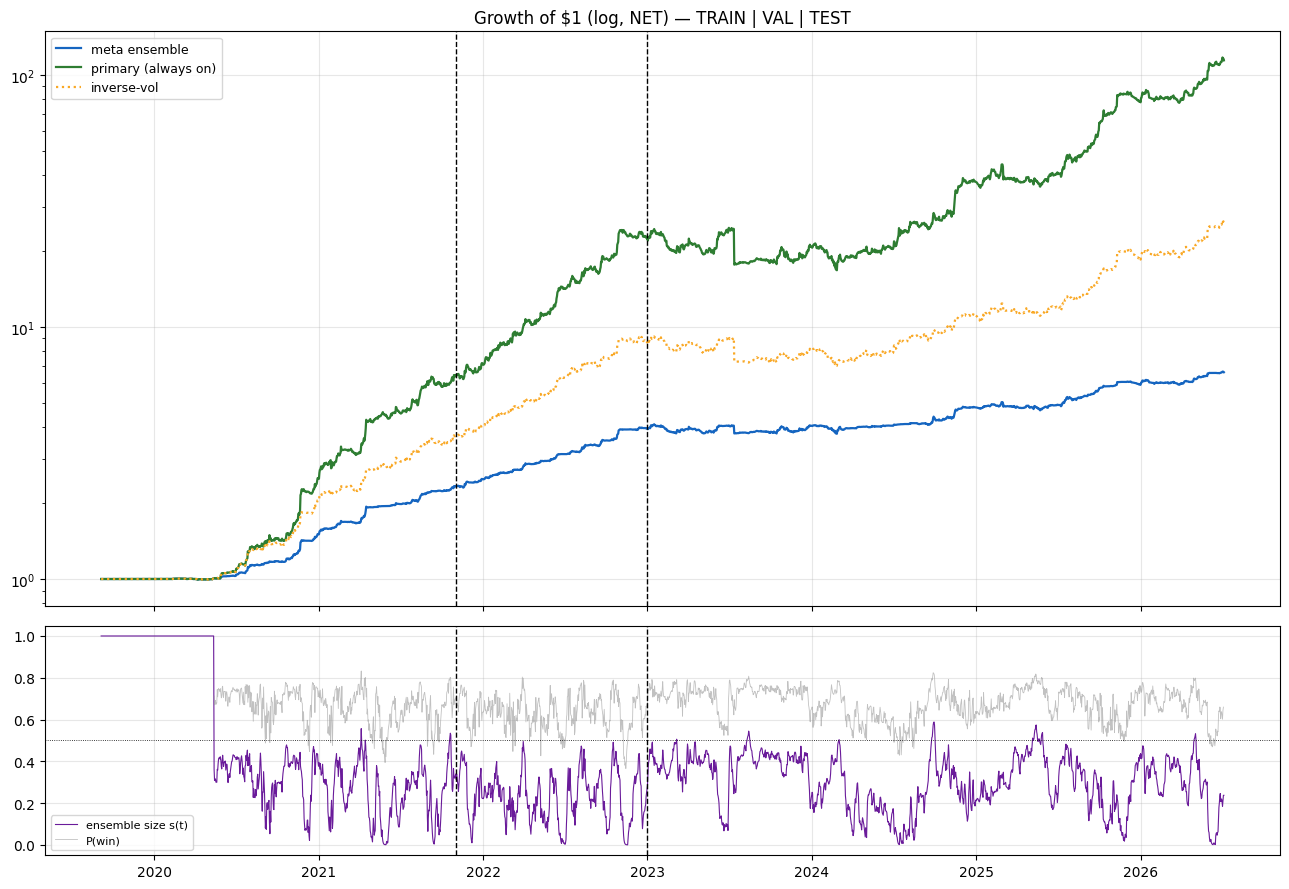

In [6]:
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(13, 9),
                              gridspec_kw={'height_ratios': [3, 1.2]}, sharex=True)
for r, lbl, col, ls in [(meta['ensemble'], 'meta ensemble', '#1565c0', '-'),
                        (p, 'primary (always on)', '#2e7d32', '-'),
                        (baselines['inverse-vol throttle'], 'inverse-vol', '#f9a825', ':')]:
    ax.plot(idx, (1 + r).cumprod(), lw=1.6, color=col, ls=ls, label=lbl)
ax.set_yscale('log'); ax.grid(alpha=0.3); ax.legend(loc='upper left', fontsize=9)
ax.set_title('Growth of $1 (log, NET) — TRAIN | VAL | TEST')
ax2.plot(idx, s_ens, lw=0.8, color='#6a1b9a', label='ensemble size s(t)')
ax2.plot(idx, PE, lw=0.6, color='#999', alpha=0.6, label='P(win)')
ax2.axhline(0.5, color='k', lw=0.6, ls=':')
ax2.set_ylim(-0.05, 1.05); ax2.grid(alpha=0.3); ax2.legend(fontsize=8, loc='lower left')
for a in (ax, ax2):
    for x in (VA, TE):
        a.axvline(x, color='k', ls='--', lw=1)
plt.tight_layout(); plt.show()

## 5. Как читать результат

- **Сначала CV AUC (блок 3).** Если он ~0.50 — мета-сигнала нет, и любые красивые
  кривые дальше — шум. Если CV ≳ 0.53 И TEST AUC его подтвердил — сигнал реальный.
- **Sharpe мета-версии почти всегда ≤ primary на бычьем куске** — она платит кэшем
  за защиту. Её настоящая работа — **просадка**: смотри TEST dd против primary.
  Улучшение dd при сравнимом Sharpe = успех мета-лейблинга.
- **Если ансамбль не бьёт inverse-vol** — весь ML свёлся к «режь размер при высокой
  воле», и однострочное правило честнее.
- Бюджет TEST потрачен: менять фичи/пороги и перезапускать «пока не понравится» —
  это уже подгонка под TEST.

**Следующие шаги, если сигнал есть:** walk-forward переобучение раз в квартал;
мета-фильтр per-alpha (глушить конкретную альфу, а не весь портфель); подключить
мета-размер в форвард-трек ноды параллельным треком и дать им гонку в реальном
времени — это окончательный судья.

## 6. Пост-фактум: недостающий бейзлайн — ПОСТОЯННЫЙ размер 0.30

Средний размер мета-ансамбля на TEST — 0.30. Честный вопрос: а что даст просто
константа 0.30 без всякого ML? Ответ (посчитано на тех же рядах): **Sharpe +1.65
(без изменений — он масштабо-инвариантен), dd −10%.**

Сравнение на TEST:

| | Sharpe | maxDD |
|---|---|---|
| meta ensemble | 1.54 | −8% |
| **константа 0.30** | **1.65** | **−10%** |
| inverse-vol | 1.55 | −23% |
| primary (полный размер) | 1.65 | −32% |

**Вердикт:** выигрыш меты по просадке почти целиком объясняется тем, что она
просто держала маленький размер, а не тем, что знала «когда». Против константного
размера она даёт −2 п.п. просадки ценой −0.11 Sharpe (косты + шумные переключения).
TEST AUC 0.512 подтверждает: пер-барного мета-сигнала вне сэмпла нет — CV AUC 0.59
был выучен на данных, где сами альфы in-sample. ML-надстройка ценности не добавила;
если нужна мелкая просадка — достаточно уменьшить target vol портфеля.